In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = torch.device("cpu")

print("Current using the device", device)

Current using the device cpu


In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("public_test.csv")
print("Training Samples: ", len(train_df))
print("Public Test Samples: ", len(test_df))
train_df.head()

Training Samples:  240
Public Test Samples:  400


,id,text,label,label_name,source_file
0,pos_cv230_7428,"well , i'll admit when i first heard about thi...",1,positive,pos/cv230_7428.txt
1,pos_cv853_29233,my summer was recently saved by two very diffe...,1,positive,pos/cv853_29233.txt
2,pos_cv771_28665,in october of 1962 the united states found its...,1,positive,pos/cv771_28665.txt
3,pos_cv449_8785,this is a good year if you want plenty of sci-...,1,positive,pos/cv449_8785.txt
4,pos_cv130_17083,"while watching wes anderson's rushmore , it ma...",1,positive,pos/cv130_17083.txt


In [5]:
train_df["label"].value_counts()

label
1    180
0     60
Name: count, dtype: int64

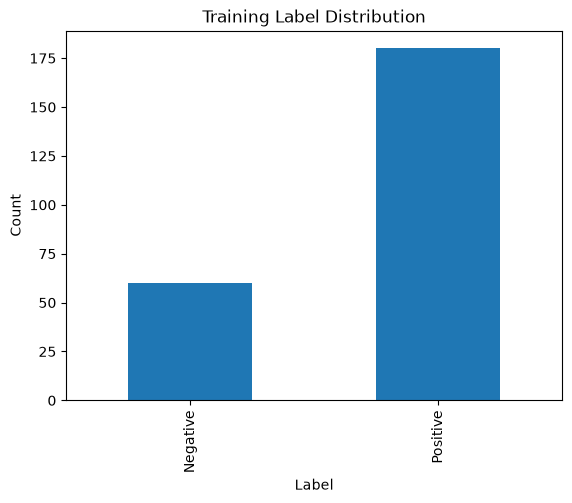

In [6]:
train_df["label"].value_counts().sort_index().plot(kind = "bar", xlabel = "Label", ylabel = "Count", title = "Training Label Distribution")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.show()

In [7]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size = 0.20,
    stratify = train_df["label"],
    random_state = 42
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))

Training Samples: 192
Validation Samples: 48


In [8]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [9]:
train_encodings = tokenizer(
    train_texts,
    truncation = True,
    padding = True,
    max_length = 256
)

val_encodings = tokenizer(
    val_texts,
    truncation = True,
    padding = True,
    max_length = 256
)

test_encodings = tokenizer(
    test_df["text"].tolist(),
    truncation = True,
    padding = True,
    max_length = 256
)

In [10]:
class MovieReviewDataset(Dataset):
    def __init__(self, encodings, labels = None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [11]:
train_dataset = MovieReviewDataset(train_encodings, train_labels)
val_dataset = MovieReviewDataset(val_encodings, val_labels)
test_dataset = MovieReviewDataset(test_encodings)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 8,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 8,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 8,
    shuffle = False
)

In [13]:
batch = next(iter(train_loader))
print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

dict_keys(['input_ids', 'attention_mask', 'labels'])
torch.Size([8, 256])
torch.Size([8, 256])
torch.Size([8])


In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels = 2
)

print("Still using the device", device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Still using the device cpu


In [15]:
weights = compute_class_weight(class_weight = "balanced", classes = np.array([0,1]), y = train_labels)

print(weights)

class_weights = torch.tensor([3.0, 1.0], dtype = torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights)

[2.         0.66666667]


In [16]:
optimizer = AdamW(model.parameters(), lr = 2e-5, weight_decay = 0.01)

In [17]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids = input_ids,
            attention_mask = attention_mask
        )

        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return (total_loss / len(dataloader))

In [18]:
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim = 1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    return accuracy

def evaluate_with_metrics(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids = input_ids,
                attention_mask = attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())

    return predictions

In [19]:
epochs = 5
best_accuracy = 0

for epoch in range(epochs):
    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_accuracy = evaluate(
        model,
        val_loader,
        device
    )

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print("-" * 40)
    
if val_accuracy > best_accuracy:
    best_accuracy = val_accuracy
    model.save_pretrained("model_checkpoint")
    tokenizer.save_pretrained("model_checkpoint")
    print("Saved the best model!")

Epoch 1/5
Training Loss: 0.6958
Validation Accuracy: 0.7500
----------------------------------------
Epoch 2/5
Training Loss: 0.6672
Validation Accuracy: 0.7500
----------------------------------------
Epoch 3/5
Training Loss: 0.5984
Validation Accuracy: 0.5208
----------------------------------------
Epoch 4/5
Training Loss: 0.3633
Validation Accuracy: 0.7083
----------------------------------------
Epoch 5/5
Training Loss: 0.1409
Validation Accuracy: 0.7917
----------------------------------------
Saved best model!


In [20]:
model = AutoModelForSequenceClassification.from_pretrained(
    "model_checkpoint"
)

model.to(device)
print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


In [21]:
def predict(model, dataloader, device):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())

    return predictions

In [22]:
public_predictions = predict(model, test_loader, device)

print(len(public_predictions))
print(public_predictions[:10])

400
[1, 1, 1, 1, 1, 0, 1, 1, 0, 0]


In [23]:
public_true_labels = test_df["label"].tolist()

public_accuracy = accuracy_score(public_true_labels, public_predictions)

print(f"Public Test Accuracy: {public_accuracy:.4f}")

Public Test Accuracy: 0.6325


In [24]:
cm = confusion_matrix(public_true_labels, public_predictions)
print(cm)

[[ 76 124]
 [ 23 177]]


In [25]:
print(classification_report(public_true_labels, public_predictions, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.77      0.38      0.51       200
    Positive       0.59      0.89      0.71       200

    accuracy                           0.63       400
   macro avg       0.68      0.63      0.61       400
weighted avg       0.68      0.63      0.61       400



In [26]:
prediction_df = pd.DataFrame({
    "id": test_df["id"],
    "predicted_label": public_predictions
})

prediction_df.to_csv(
    "public_test_predictions.csv",
    index=False
)

prediction_df.head()

,id,predicted_label
0,pos_cv696_29740,1
1,pos_cv669_22995,1
2,neg_cv963_7208,1
3,pos_cv182_7281,1
4,pos_cv162_10424,1


# Markdown Section

### **Model Structure:** This assignment uses the pretrained DistilBERT transformer model and it is fine-tuned as "distilbert-base-uncased" for binary sentiment classification in order for the model to run better for me.  The classification layer was replaced with a two-output layer of negative/positive in order to predict the two sentiment classes, which these sentiment labels were not used to replace the final classification layer.

### **Handling the small and imbalanced training set:** 
#### - Training Set Size: 240 Reviews
#### - Distribution: 180 Positive Reviews and 60 Negative Reviews
#### - Stratified Validation Split
#### - Weighted Loss Function
#### - Validation-Based Checkpoint Selection

#### Because this was a very small and imbalanced dataset, the class weights were applied while training the model by using a weighted cross-entropy loss.  Also stratified validation split was used to keep the original label distribution and the best model checkpoint was the validation accuracy in order to reduce the amount of overfitting.

### **Key Training Techniques (Such as the choice of learning rate, optimizer, batch size):**
#### - Optimizer: AdamW
#### - Learning Rate: 2E-5 or 2*10^-5
#### - Batch Size: 8
#### - Number of Epochs: 5
#### - Weight Decay: 0.01
#### - Maximum Sequence Length: 256

### **Evaluation Result and Confusion Matrix:**
#### - Public Test Accuracy: 63.25%
#### - Confusion Matrix: [[76 124] , [23 177]]

### **Use of A.I. Section:**
#### I used ChatGPT Atlas to assist me with this assignment step-by-step in order for me to complete this assignment.  It was used for me to assist me into the concepts, troubleshooting coding problems, and also debugging my implementing while developing the code.  I reviewed, tested, and made sure that all of the generated code was running correctly before finalizing it.